# 02. Boosting 모델 학습

학습 기간 유연 설정 (PERIOD_MODE 사용)

In [ ]:
import pandas as pd, numpy as np, warnings
import xgboost as xgb, lightgbm as lgb, optuna
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from catboost import CatBoostRegressor,CatBoostClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter
import optuna
from sklearn.metrics import r2_score
optuna.logging.set_verbosity(optuna.logging.WARNING)  # 로그 최소화

N_TRIALS = 100
import sklearn.preprocessing
import pickle

smote = SMOTE(random_state=42)
warnings.filterwarnings("ignore")
# ════════════════════════════════════════════════
# ✏️  학습 기간 설정 (세 가지 방식 중 하나만 선택)
# ════════════════════════════════════════════════

PERIOD_MODE = "from"       # "range"   : 특정 구간만 학습
                            # "exclude" : 특정 구간을 제외하고 학습
                            # "from"    : 특정 연도 이후만 학습 (기존 방식)

PERIOD_START = 2020         # 구간 시작 연도 (range / exclude 공통)
PERIOD_END   = 2021       # 구간 종료 연도 (range / exclude 공통)
MIN_YEAR     = 2016         # "from" 모드일 때만 사용
# ════════════════════════════════════════════════

# 설정
FEATURE_VERSION = "v2"
SPLIT_STRATEGY = "year"
TARGET_TYPE = "regression" # regression , classification
TEST_SIZE = 0.2
RANDOM_STATE = 42
ENABLE_TUNING = True
N_TRIALS = 50
CV_FOLDS = 5
print(f"✅ 설정 완료: {FEATURE_VERSION}, PERIOD_MODE = {PERIOD_MODE}, PERIOD_START = {PERIOD_START}, PERIOD_END = {PERIOD_END} ,MIN_YEAR = {MIN_YEAR}")

✅ 설정 완료: v2, PERIOD_MODE = from, PERIOD_START = 2020, PERIOD_END = 2021 ,MIN_YEAR = 2016


In [373]:
# 데이터 로드
df = pd.read_csv(f"data/processed/feature_table_{FEATURE_VERSION}.csv", encoding="utf-8-sig")

# open_date를 datetime으로 변환 (결측치 처리)
df["open_date"] = pd.to_datetime(df["open_date"], errors="coerce")

# open_year 추출
df["open_year"] = df["open_date"].dt.year.astype("Int64")  # NaT 허용하는 정수형

# 코로나 기간 제외
# df = (
#     df[~df['open_year'].isin([2020, 2021])]
#     .reset_index(drop=True)
# )

# 감독-배우 조합 과거 평균
# df['director_actor_combo_count'] = df.groupby(['director', 'lead_actor'])['movie_id'].transform('count')
# 검증
print(f"✅ {FEATURE_VERSION} 로드: {df.shape[0]:,}편")
print(f"   개봉 년도: {int(df['open_year'].min())}~{int(df['open_year'].max())}")
print(f"   open_date 결측치: {df['open_date'].isna().sum()}건")

✅ v2 로드: 2,454편
   개봉 년도: 2016~2025
   open_date 결측치: 0건


In [374]:
# PERIOD_MODE에 따라 학습 데이터 필터링

if PERIOD_MODE == "range":
    # 특정 구간만 학습 (예: 2012~2020)
    mask = (df["open_year"] >= PERIOD_START) & (df["open_year"] <= PERIOD_END)
    desc = f"{PERIOD_START}~{PERIOD_END}년"

elif PERIOD_MODE == "exclude":
    # 특정 구간 제외 (예: 코로나 2020~2021 제외)
    mask = ~((df["open_year"] >= PERIOD_START) & (df["open_year"] <= PERIOD_END))
    desc = f"{PERIOD_START}~{PERIOD_END}년 제외"

elif PERIOD_MODE == "from":
    # 특정 연도 이후만 (기존 방식)
    mask = df["open_year"] >= MIN_YEAR
    desc = f"{MIN_YEAR}년 이후"


print(f"📅 학습 기간 모드  : {PERIOD_MODE} ({desc})")


📅 학습 기간 모드  : from (2016년 이후)


In [375]:
# hit_class 재구성,(기본 0,1,2,3[0~100,100~300,300~500,500~])
REMAP = {0: 0, 1: 1, 2: 1, 3: 1}  # 100만 미만=0, 이상=1
df['hit_class'] = df['hit_class'].map(REMAP).astype('Int64')

print(df['hit_class'].value_counts().sort_index())
# 예상: 0 → 2121편 / 1 → 333편  (약 6.4:1)

hit_class
0    2121
1     333
Name: count, dtype: Int64


### v3 제안해볼만한 feature 추가 테스트 !!

In [376]:
# 성수기에 검색량까지 높으면 시너지
df['peak_x_trend'] = df['is_peak_season'] * df['trend_pre7_avg']

# 배급사 + 제작사 + 감독 + 배우 평균을 가중 합산
df['brand_power_score'] = (
    df['distributor_avg_audi'] * 0.4 +
    df['producer_avg_audi']    * 0.2 +
    df['director_avg_audi']    * 0.2 +
    df['lead_actor_avg_audi']  * 0.2
)

# → 근사치: 두 avg가 비슷한 수준이면 시너지 있다고 판단
df['star_director_synergy'] = (
    df['director_avg_audi'] * df['lead_actor_avg_audi']
).apply(np.log1p)

# 같은 주 개봉작 수 대비 시장 평균 관객 → 경쟁이 치열한데 시장도 작으면 불리
df['competition_pressure'] = (
    df['same_week_releases'] / (df['market_avg_audi_7d'] + 1)
).apply(np.log1p)

# 검색량 최고점 대비 평균 비율 → 검색이 특정일 폭발적인지 vs 꾸준한지
df['trend_peak_ratio'] = (
    df['trend_pre7_max'] / (df['trend_pre7_avg'] + 1e-6)
).clip(upper=10)  # 이상치 제한

# 검색량은 높은데 감독/배우 실적이 낮은 경우 → 기대작이지만 검증 안 된 경우
df['hype_vs_track'] = (
    df['trend_pre7_avg'] / (df['director_avg_audi'] + df['lead_actor_avg_audi'] + 1)
).apply(np.log1p)

# 편수 많고 평균 높으면 → 검증된 배급사
df['distributor_reliability'] = (
    df['distributor_avg_audi'] * np.log1p(df['distributor_movie_count'])
)

In [377]:
drop_cols = [
    # 상관관계 0에 수렴 → 노이즈
    'open_month',        # open_day_of_week, is_summer/winter로 커버됨
    'trend_peak_ratio',  # trend_pre7_avg, trend_pre7_max으로 커버됨
    'distributor_reliability',  # distributor_avg_audi와 거의 동일 정보
    
    # is_summer/is_winter/is_peak_season 중복
    'is_summer',         # is_peak_season에 흡수됨
    'is_winter',         # is_peak_season에 흡수됨
    
    # is_new_* 시리즈 → 상관관계 0 근처, avg_audi가 0인 경우 이미 중위값 대체됨
    'is_new_distributor',
    'is_new_producer',
    'is_new_lead',
    'is_new_director'
]

drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

print(f'제거된 피처: {drop_cols}')
print(f'남은 피처 수: {len(df.columns)}')

제거된 피처: ['open_month', 'trend_peak_ratio', 'distributor_reliability', 'is_summer', 'is_winter', 'is_new_distributor', 'is_new_producer', 'is_new_lead', 'is_new_director']
남은 피처 수: 38


In [378]:
# Int64 (nullable) → int64로 통일 (XGB/LGBM에서 간헐적 오류 방지)
df['open_year'] = df['open_year'].astype('int64')

# avg_audi 계열은 이미 log 변환됐는지 확인 필요
log_cols = [
    'director_avg_audi',
    'lead_actor_avg_audi', 
    'distributor_avg_audi',
    'producer_avg_audi',
    'market_avg_audi_7d',
    'genre_avg_audi',
    'cast_max_star_power',
]

for col in log_cols:
    if df[col].max() > 1000:  # 아직 log 변환 안 된 경우만
        df[col] = np.log1p(df[col])
        print(f'log1p 적용: {col}')

# competition_pressure, hype_vs_track은 극단값 있을 수 있음
clip_cols = ['competition_pressure', 'hype_vs_track', 'trend_peak_ratio']

for col in clip_cols:
    if col in df.columns:
        upper = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper)
        print(f'클리핑 적용: {col} (상한: {upper:.4f})')



log1p 적용: cast_max_star_power
클리핑 적용: competition_pressure (상한: 1.0850)
클리핑 적용: hype_vs_track (상한: 1.0021)


In [380]:
# 피처 준비
df_train = df[mask].copy()
target_col = "log_audience" if TARGET_TYPE == "regression" else "hit_class"
y = df_train[target_col].copy()
exclude_cols = ["movie_id", "title", "total_audience", "log_audience", "hit_class", "open_date", "open_year"]
feature_cols = [c for c in df_train.columns if c not in exclude_cols]
X = df_train[feature_cols].copy()
# 상위 8개 장르만 원핫 (나머지는 '기타'로 묶음)
TOP_GENRES = ['애니메이션', '드라마', '액션', '코미디', '공포(호러)', '다큐멘터리', '범죄', '멜로/로맨스']

X['genre_grouped'] = X['genre'].apply(lambda x: x if x in TOP_GENRES else '기타')
genre_dummies = pd.get_dummies(X['genre_grouped'], prefix='genre', dtype=int)
X = pd.concat([X.drop(columns=['genre', 'genre_grouped']), genre_dummies], axis=1)

# 범주형 인코딩
# for col in X.select_dtypes(include=["object"]).columns:
#     X[col] = LabelEncoder().fit_transform(X[col].astype(str))
print(f"피처: {len(feature_cols)}, 샘플: {len(y):,}")
print(f"   전체 데이터     : {len(df):,}편")
print(f"   학습 데이터     : {len(df_train):,}편")
print(f"   제외 데이터     : {len(df) - len(df_train):,}편")
print(f"   개봉 년도 범위  : {int(df_train['open_year'].min())}~{int(df_train['open_year'].max())}")

피처: 31, 샘플: 2,454
   전체 데이터     : 2,454편
   학습 데이터     : 2,454편
   제외 데이터     : 0편
   개봉 년도 범위  : 2016~2025


In [394]:
df.head()

,movie_id,title,runtime,rating_encoded,is_korean,genre,open_date,open_day_of_week,is_holiday_release,holiday_nearby_count,...,is_covid_period,is_peak_season,ticket_price_pre30,genre_avg_audi,open_year,peak_x_trend,brand_power_score,star_director_synergy,competition_pressure,hype_vs_track
0,19818004,불의 전차,123.0,1.0,0.0,드라마,2016-06-16,3.0,0,0,...,0,0,7993.272093,12.861455,2016,0.000000,2.634335,2.099052,0.000000,0.038173
1,19838068,해탄적일천,166.0,1.0,0.0,드라마,2022-01-06,3.0,0,0,...,1,1,9859.892076,12.984166,2022,0.081429,2.566338,1.921464,0.606793,0.013795
2,19978805,큐어,111.0,2.0,0.0,공포(호러),2022-07-06,2.0,0,0,...,0,1,10234.188266,12.683620,2022,0.147143,2.399964,1.915077,0.437692,0.024968
3,19988717,명탐정 코난: 14번째 표적,99.0,1.0,0.0,애니메이션,2025-02-14,4.0,0,0,...,0,0,9532.658866,12.657033,2025,0.000000,2.652629,2.055492,0.247551,0.001147
4,20021031,남색대문,83.0,1.0,0.0,드라마,2021-08-18,2.0,0,1,...,1,1,9587.370927,13.044063,2021,0.144286,2.579688,2.033483,0.868300,0.023170


In [381]:
# Train/Test 분할
if SPLIT_STRATEGY == "year":
    sorted_idx = df_train.sort_values("open_year").index
    split_idx = int(len(sorted_idx) * (1 - TEST_SIZE))
    train_idx, test_idx = sorted_idx[:split_idx], sorted_idx[split_idx:]
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]
else:
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y,test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

Train: 1,963, Test: 491


In [382]:
counter = Counter(y_train)
neg, pos = counter[0], counter[1]

print(f'class 0 (일반): {neg}, class 1 (흥행): {pos}')

class 0 (일반): 0, class 1 (흥행): 0


In [383]:
# smote 적용
smote = SMOTE(random_state=42)

In [384]:
# XGBoost
if TARGET_TYPE == "regression":
    xgb_model = xgb.XGBRegressor(max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbosity=0,class_weight='balanced')
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ XGBoost: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    scale = neg / pos  # XGB용
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    xgb_model = xgb.XGBClassifier(objective="multi:softmax", num_class=4, max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbosity=0,class_weight='balanced',scale_pos_weight=scale,eval_metric='logloss')
    xgb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = xgb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[:, 1]
    # 0.5 → 0.3으로 낮추면 흥행 recall 올라감 (precision과 트레이드오프)
    threshold = 0.3
    y_pred_adj = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ XGBoost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred_adj)
    print(cm)
    print(classification_report(y_test, y_pred_adj))

✅ XGBoost: RMSE=1.4240, R²=0.5220


In [ ]:
# xgb optuna
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'random_state': 42
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    return r2_score(y_test, model.predict(X_test))

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS)
print('XGB 최적 R2:', study_xgb.best_value)
print('XGB 최적 파라미터:', study_xgb.best_params)

[I 2026-05-21 18:26:22,956] A new study created in memory with name: no-name-82e49d01-23e3-451c-ba98-87bb65ad7a9e
[I 2026-05-21 18:26:24,737] Trial 0 finished with value: 0.5413970068813427 and parameters: {'n_estimators': 591, 'max_depth': 8, 'learning_rate': 0.03584369345494196, 'subsample': 0.6202598864816289, 'colsample_bytree': 0.6230702732529817, 'min_child_weight': 7, 'reg_alpha': 0.873432573177465, 'reg_lambda': 1.8574267952320327e-06}. Best is trial 0 with value: 0.5413970068813427.
[I 2026-05-21 18:26:27,251] Trial 1 finished with value: 0.5279594333280158 and parameters: {'n_estimators': 1347, 'max_depth': 7, 'learning_rate': 0.06153645708595954, 'subsample': 0.6420424443411579, 'colsample_bytree': 0.8117052505289946, 'min_child_weight': 9, 'reg_alpha': 0.00013409039273705835, 'reg_lambda': 6.198380041991304e-05}. Best is trial 0 with value: 0.5413970068813427.
[I 2026-05-21 18:26:27,975] Trial 2 finished with value: 0.5507230205939273 and parameters: {'n_estimators': 534, '

XGB 최적 R2: 0.5704972649360338
XGB 최적 파라미터: {'n_estimators': 1761, 'max_depth': 3, 'learning_rate': 0.005028267702884872, 'subsample': 0.9730405384225651, 'colsample_bytree': 0.5613052651891169, 'min_child_weight': 8, 'reg_alpha': 1.0398866062207404, 'reg_lambda': 2.12734419529932}


In [385]:
# LightGBM
if TARGET_TYPE == "regression":
    lgb_model = lgb.LGBMRegressor(max_depth=6, learning_rate=0.1, n_estimators=100, random_state=RANDOM_STATE, verbose=-1)
    lgb_model.fit(X_train, y_train)
    y_pred = lgb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ LightGBM: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    lgb_model = lgb.LGBMClassifier(objective="multiclass", num_class=4, max_depth=6, learning_rate=0.1, n_estimators=100, class_weight='balanced',random_state=RANDOM_STATE, verbose=-1)
    lgb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = lgb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[:, 1]
    # 0.5 → 0.3으로 낮추면 흥행 recall 올라감 (precision과 트레이드오프)
    threshold = 0.3
    y_pred_adj = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ XGBoost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred_adj)
    print(cm)
    print(classification_report(y_test, y_pred_adj))

✅ LightGBM: RMSE=1.4114, R²=0.5304


In [ ]:
# LGBM optuna
def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 300),
        'random_state': 42,
        'verbose': -1
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    return r2_score(y_test, model.predict(X_test))

study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS)
print('LGB 최적 R2:', study_lgb.best_value)
print('LGB 최적 파라미터:', study_lgb.best_params)

[I 2026-05-21 18:28:26,686] A new study created in memory with name: no-name-3f978182-b3c4-40cf-83a4-fac1746694cd
[I 2026-05-21 18:28:26,926] Trial 0 finished with value: 0.562324039094186 and parameters: {'n_estimators': 443, 'max_depth': 3, 'learning_rate': 0.007548282006726749, 'subsample': 0.6693702088794037, 'colsample_bytree': 0.877048869060749, 'min_child_samples': 64, 'reg_alpha': 1.3102693309723002e-08, 'reg_lambda': 6.591971437589373e-08, 'num_leaves': 201}. Best is trial 0 with value: 0.562324039094186.
[I 2026-05-21 18:28:27,054] Trial 1 finished with value: 0.5627691615947021 and parameters: {'n_estimators': 1237, 'max_depth': 5, 'learning_rate': 0.03764343346720621, 'subsample': 0.9820894567408807, 'colsample_bytree': 0.5035354876180724, 'min_child_samples': 87, 'reg_alpha': 2.800499726640177e-08, 'reg_lambda': 0.0380387184786296, 'num_leaves': 129}. Best is trial 1 with value: 0.5627691615947021.
[I 2026-05-21 18:28:27,230] Trial 2 finished with value: 0.5597852126233176

LGB 최적 R2: 0.5747537470376813
LGB 최적 파라미터: {'n_estimators': 1987, 'max_depth': 3, 'learning_rate': 0.024541617492404518, 'subsample': 0.7677087776374905, 'colsample_bytree': 0.5069533527110249, 'min_child_samples': 16, 'reg_alpha': 1.7946914940190934, 'reg_lambda': 0.00022703063579205298, 'num_leaves': 205}


In [386]:
# Catboost
if TARGET_TYPE == "regression":
    cb_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    eval_metric='R2',
    verbose=100
)
    cb_model.fit(X_train, y_train)
    y_pred = cb_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"✅ Catboost: RMSE={rmse:.4f}, R²={r2:.4f}")
else:
    X_train_resampled, y_train_resampled = smote.fit_resample(
        X_train,
        y_train
    )
    cb_model = CatBoostClassifier(
    loss_function='Logloss',   # 이진분류
    eval_metric='F1',          # 불균형 데이터니까 F1 권장
    depth=6,
    learning_rate=0.03,
    iterations=2000,
    l2_leaf_reg=5,
    random_state=42,
    verbose=0,
    class_weights=[1, scale]
    )
    cb_model.fit(X_train_resampled, y_train_resampled)
    y_pred = cb_model.predict(X_test)
    y_prob = xgb_model.predict_proba(X_test)[:, 1]
    # 0.5 → 0.3으로 낮추면 흥행 recall 올라감 (precision과 트레이드오프)
    threshold = 0.3
    y_pred_adj = (y_prob >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ XGBoost: Accuracy={acc:.4f}")
    cm = confusion_matrix(y_test, y_pred_adj)
    print(cm)
    print(classification_report(y_test, y_pred_adj))

0:	learn: 0.0294276	total: 3.66ms	remaining: 7.31s
100:	learn: 0.7315089	total: 271ms	remaining: 5.1s
200:	learn: 0.7868464	total: 557ms	remaining: 4.99s
300:	learn: 0.8163438	total: 855ms	remaining: 4.83s
400:	learn: 0.8419242	total: 1.18s	remaining: 4.71s
500:	learn: 0.8631778	total: 1.5s	remaining: 4.5s
600:	learn: 0.8810794	total: 1.77s	remaining: 4.13s
700:	learn: 0.8940023	total: 2.07s	remaining: 3.84s
800:	learn: 0.9060161	total: 2.38s	remaining: 3.57s
900:	learn: 0.9151670	total: 2.75s	remaining: 3.35s
1000:	learn: 0.9234288	total: 3.02s	remaining: 3.02s
1100:	learn: 0.9298932	total: 3.3s	remaining: 2.7s
1200:	learn: 0.9362182	total: 3.56s	remaining: 2.37s
1300:	learn: 0.9420168	total: 3.84s	remaining: 2.06s
1400:	learn: 0.9471669	total: 4.13s	remaining: 1.76s
1500:	learn: 0.9519427	total: 4.39s	remaining: 1.46s
1600:	learn: 0.9560410	total: 4.65s	remaining: 1.16s
1700:	learn: 0.9604407	total: 4.94s	remaining: 869ms
1800:	learn: 0.9641017	total: 5.21s	remaining: 575ms
1900:	lea

In [ ]:
# Catboost optuna
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 2000),
        'depth': trial.suggest_int('depth', 3, 8),          # CatBoost는 8이 실질적 한계
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 10, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 50),
        'random_state': 42,
        'verbose': 0
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_test, y_test),
              early_stopping_rounds=50, verbose=False)
    return r2_score(y_test, model.predict(X_test))

study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=N_TRIALS)
print('CAT 최적 R2:', study_cat.best_value)
print('CAT 최적 파라미터:', study_cat.best_params)

[I 2026-05-21 18:28:51,858] A new study created in memory with name: no-name-62e08551-46ba-442d-b12a-9704fca0d91c
[I 2026-05-21 18:28:53,994] Trial 0 finished with value: 0.5858861292990345 and parameters: {'iterations': 329, 'depth': 7, 'learning_rate': 0.00898827707739518, 'l2_leaf_reg': 0.0007699669096833705, 'subsample': 0.9467166473665959, 'colsample_bylevel': 0.7259448937214732, 'min_data_in_leaf': 43}. Best is trial 0 with value: 0.5858861292990345.
[I 2026-05-21 18:28:54,387] Trial 1 finished with value: 0.5977172517544269 and parameters: {'iterations': 1688, 'depth': 5, 'learning_rate': 0.08950029554679077, 'l2_leaf_reg': 3.881690429289255e-05, 'subsample': 0.8831289442477366, 'colsample_bylevel': 0.8178942504690412, 'min_data_in_leaf': 36}. Best is trial 1 with value: 0.5977172517544269.
[I 2026-05-21 18:28:54,933] Trial 2 finished with value: 0.6001161943262137 and parameters: {'iterations': 1245, 'depth': 6, 'learning_rate': 0.07142851150994704, 'l2_leaf_reg': 0.00018369113

CAT 최적 R2: 0.606044239219965
CAT 최적 파라미터: {'iterations': 1453, 'depth': 7, 'learning_rate': 0.04657941255544304, 'l2_leaf_reg': 0.10981974965802035, 'subsample': 0.7057753216799993, 'colsample_bylevel': 0.5025807363682381, 'min_data_in_leaf': 34}


In [400]:
# 잔차 분석 - 어떤 영화를 틀리고 있는지
y_pred = xgb_model.predict(X_test)
residuals = y_test - y_pred

# 많이 틀리는 영화 확인
error_df = pd.DataFrame({
    'title': df.loc[X_test.index, 'title'],
    'actual': y_test,
    'predicted': y_pred,
    'error': residuals.abs()
}).sort_values('error', ascending=False)

print(error_df.head(20))

                    title     actual  predicted     error
2430       극장판 체인소 맨: 레제편  15.047054   9.933344  5.113710
2177   캡틴 아메리카: 브레이브 뉴 월드  14.317896   9.240132  5.077764
2254                 건국전쟁  13.972494   8.991115  4.981379
2372     극장판 귀멸의 칼날: 무한성편  15.549735  10.968575  4.581159
2352       쥬라기 월드: 새로운 시작  14.601288  10.290144  4.311144
2153           베놈: 라스트 댄스  14.380803  10.128428  4.252375
2214                썬더볼츠＊  13.729025   9.532451  4.196575
2427    긴키 지방의 어느 장소에 대하여  12.503295   8.475597  4.027698
2108       스즈메의 문단속: 다녀왔어  10.091460  14.085076  3.993617
900        보고타: 마지막 기회의 땅  12.913056   9.202932  3.710124
2301                노스페라투   8.506941  12.118914  3.611973
2355       판타스틱 4: 새로운 출발  13.249544   9.638459  3.611085
2242     미션 임파서블: 파이널 레코닝  15.033608  11.450299  3.583309
2179      브레드이발소: 빵스타의 탄생  12.477061   8.904828  3.572233
2004                  노이즈  14.346048  10.777191  3.568857
2425  브레드이발소: 베이커리타운의 악당들  12.528989   9.038072  3.490917
2157    그 시절, 

# Feature Correlation / Importance 분석 셀

## 1. log_audience와 상관계수 높은 feature 출력

In [387]:
# Boosting 학습 파일에 추가할 Feature Correlation / Importance 분석 셀
import matplotlib.pyplot as plt
import seaborn as sns

# 분석 대상 컬럼
exclude_cols = [
    'movie_id',
    'title',
    'genre',
    'open_date',
    'total_audience',
    'hit_class'
]

numeric_cols = [
    col for col in df.columns
    if col not in exclude_cols
]

# 상관계수 계산
corr_series = (
    df[numeric_cols]
    .corr()['log_audience']
    .drop('log_audience')
    .sort_values(key=abs, ascending=False)
)

print('=' * 60)
print(f'{FEATURE_VERSION} log_audience 와의 상관계수 TOP 15')
print('=' * 60)
print(corr_series.head(15))

v2 log_audience 와의 상관계수 TOP 15
hype_vs_track            0.581817
brand_power_score        0.568343
distributor_avg_audi     0.481734
trend_pre7_avg           0.470247
relative_search_share    0.425951
cast_max_star_power      0.361124
trend_pre7_max           0.350843
star_director_synergy    0.349515
runtime                  0.294427
lead_actor_avg_audi      0.292984
market_avg_audi_7d       0.284050
is_covid_period         -0.281319
peak_x_trend             0.280755
genre_avg_audi           0.265529
director_avg_audi        0.255595
Name: log_audience, dtype: float64


## 2. 상관계수 시각화

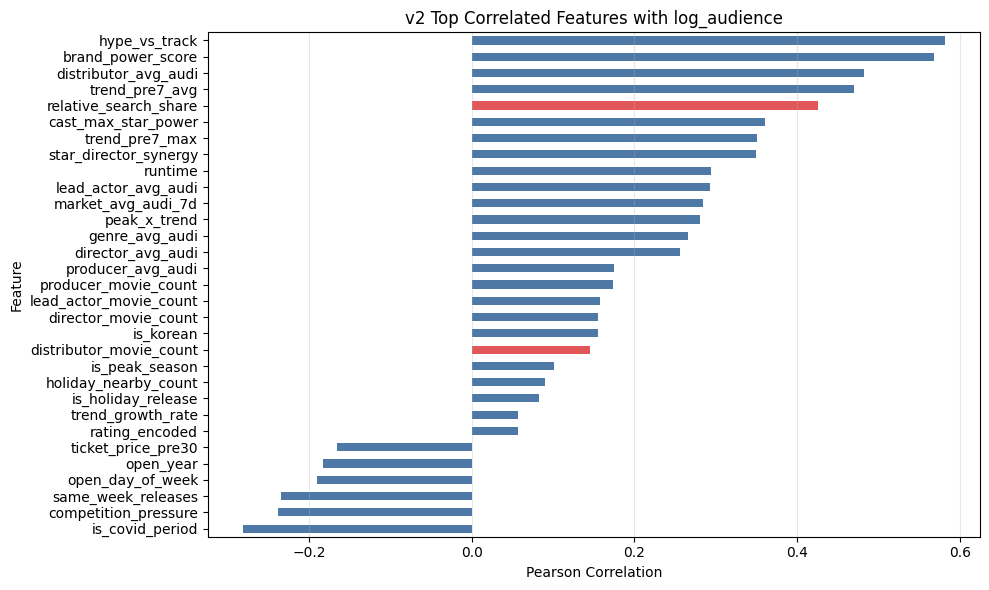

In [388]:
plt.figure(figsize=(10, 6))

colors = [
    '#4e79a7' if v > 0 else '#e15759'
    for v in corr_series.head(15).values
]

corr_series.sort_values().plot(
    kind='barh',
    color=colors
)

plt.title(f'{FEATURE_VERSION} Top Correlated Features with log_audience')
plt.xlabel('Pearson Correlation')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 전체 Feature Heatmap

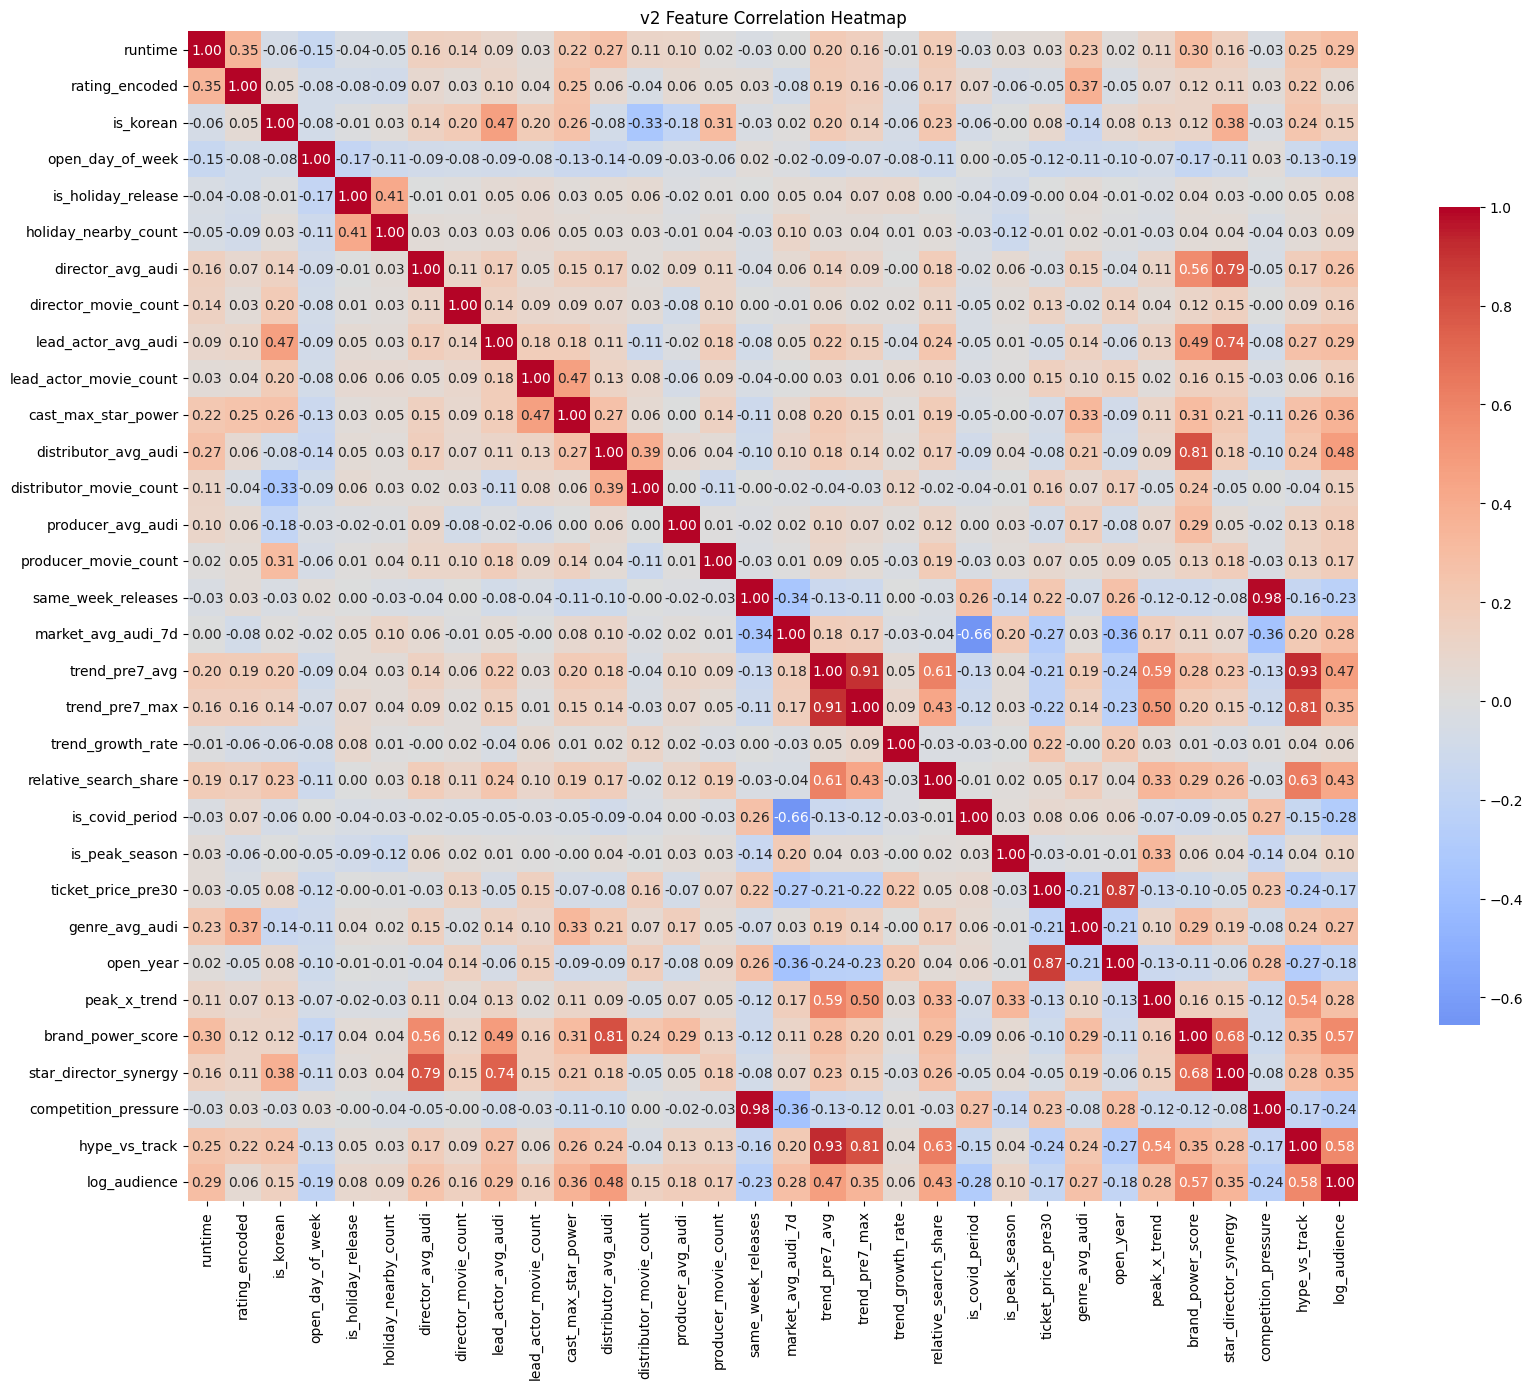

In [389]:
# =====================================================
# Feature Heatmap
# =====================================================

heatmap_cols = [
    col for col in numeric_cols
    if col != 'log_audience'
]

corr_matrix = df[
    heatmap_cols + ['log_audience']
].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f',
    square=True,
    cbar_kws={'shrink': 0.7}
)

plt.title(f'{FEATURE_VERSION} Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. CatBoost Feature Importance 시각화

In [390]:
# =====================================================
# CatBoost Feature Importance
# =====================================================

feature_names = X.columns

cat_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': cb_model.feature_importances_
})

cat_importance = (
    cat_importance
    .sort_values('importance', ascending=False)
)
cat_importance=cat_importance.reset_index()
print('=' * 60)
print(f'{FEATURE_VERSION} CatBoost Feature Importance TOP 20')
print('=' * 60)

display(cat_importance.head(20))

v2 CatBoost Feature Importance TOP 20


,index,feature,importance
0,17,trend_pre7_avg,10.466764
1,26,brand_power_score,8.945286
2,18,trend_pre7_max,8.217781
3,23,ticket_price_pre30,6.346390
4,29,hype_vs_track,6.109963
5,11,distributor_avg_audi,5.777834
6,0,runtime,4.599830
7,19,trend_growth_rate,4.474351
8,20,relative_search_share,3.860154
9,12,distributor_movie_count,3.650752


## 5. Feature Importance 시각화

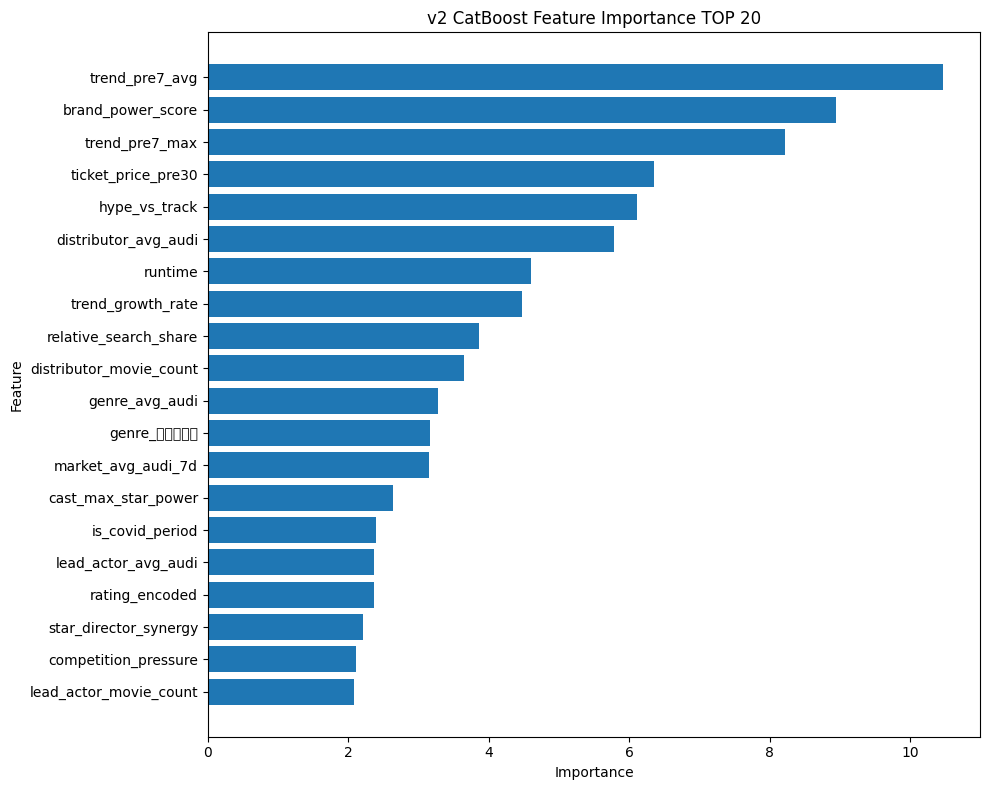

In [391]:
plt.figure(figsize=(10, 8))

plot_df = cat_importance.head(20).sort_values('importance')

plt.barh(
    plot_df['feature'],
    plot_df['importance']
)

plt.title(f'{FEATURE_VERSION} CatBoost Feature Importance TOP 20')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [392]:
# 모드별 파일명 자동 생성
period_tag = {
    "range"  : f"{PERIOD_START}_{PERIOD_END}",
    "exclude": f"ex{PERIOD_START}_{PERIOD_END}",
    "from"   : f"from{MIN_YEAR}",
}[PERIOD_MODE]

model_prefix = f"{FEATURE_VERSION}_{period_tag}"

with open(f"models/{model_prefix}_xgboost.pkl", "wb") as f:
    pickle.dump(xgb_model, f)
with open(f"models/{model_prefix}_lightgbm.pkl", "wb") as f:
    pickle.dump(lgb_model, f)
with open(f"models/{model_prefix}_catboost.pkl", "wb") as f:
    pickle.dump(cb_model, f)

print(f"✅ 모델 저장 완료: models/{model_prefix}_*.pkl")

✅ 모델 저장 완료: models/v2_from2016_*.pkl


In [393]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2454 entries, 0 to 2453
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   movie_id                 2454 non-null   str           
 1   title                    2454 non-null   str           
 2   runtime                  2454 non-null   float64       
 3   rating_encoded           2454 non-null   float64       
 4   is_korean                2454 non-null   float64       
 5   genre                    2454 non-null   str           
 6   open_date                2454 non-null   datetime64[us]
 7   open_day_of_week         2454 non-null   float64       
 8   is_holiday_release       2454 non-null   int64         
 9   holiday_nearby_count     2454 non-null   int64         
 10  director_avg_audi        2454 non-null   float64       
 11  director_movie_count     2454 non-null   int64         
 12  lead_actor_avg_audi      2454 non-null   floa